<a href="https://colab.research.google.com/github/rcpaffenroth/DS595-Machine-Learning-for-Engineering-and-Science-Applications/blob/main/CaseStudy_3_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BEFORE YOU START!!!

This notebook will run Neural Networks, which can make use of GPU machines to speed up training. **To use GPU in the colab: Click Runtime (Upper left corner) → Change runtime type → Hardware accelerator → T4 GPU → Save**

On the right hand side, if you see the name `T4` and the green checkmark, you're all set!

## Important Note:

Colab will be upset if you reserve a GPU and then do not use it. The GPU will be used after question 4. Thus, Randy really recommends that you do NOT ask for a GPU UNLESS you get past Question 4. If you are doing Questions 1-4, start with a CPU and finish your coding and answering of questions. Once you finish question 4, follow the steps above to SWITCH to a GPU, re-run all of the code cells again, and proceed from there.

### Why do we do this?
If you reserve the GPU and do not use it (in this notebook, train any neural networks), Colab will not like that and after a certain amount of time will
kill your GPU machine and prevent you from reserving a GPU for the day. It can be very annoying, but just keep in mind if you are not running any of the neural network cells, then it is a good idea to use the CPU until you are ready for the training of the neural networks parts. When you are ready, follow the steps above and run all of the cells up unto where you are.

## Electric field Measurement ##

This case study is based upon the excellent real world machine learning problem, you can find more detail below:

[Deep Learning for Range Localization via Over-Water Electromagnetic Signals](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9680246)

**Background:** As a signal moves through the humid air above the ocean, it bounces through layers of humidity known as *evaporation ducts*. This traps and distorts the signal, which you'd think would be bad for us, but it's actually very helpful! This is what allows us to distinguish different signal measurements at different ranges. We have a signal that looks like this:

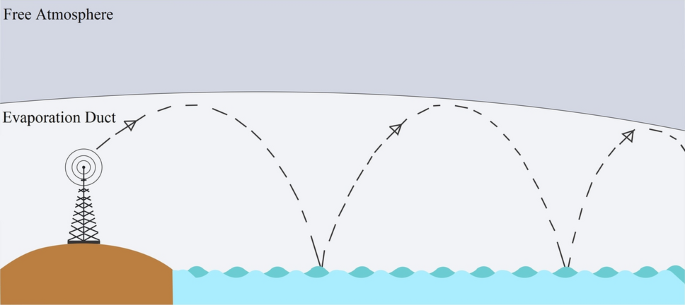


So how do we measure this? Let's imagine there's a boat out on the ocean sending a signal, and we're at a signal receiver on shore. We want to figure out how far away the boat is. In theory, can we even do that?


**Objective:**  Our goal here is to come up with a function that takes in an electromagnetic signal (e.g. radio waves) and output the distance that the signal came from.

**Data:** For this problem, our input data is a measurement of the electric field that we see from the transmitter. We measure the electric field with an antenna:

![](https://20fd661yccar325znz1e9bdl-wpengine.netdna-ssl.com/wp-content/uploads/2021/03/best-outdoor-antenna-scaled-e1616606936465.jpeg)

Do you see the 8 X shaped antennae in the image? Each one of those is a signal receiver. We're measuring in a very similar way, except that instead of 8 receivers, we have 40. Additionally, the fact that the receivers are X shaped is a big deal, since they measure light at different polarizations. As we know, light is a wave, and it can oscillate in any orientation - vertically, horizontally, or anything in between.

![](https://www.specac.com/getattachment/news/calendar/2018/04/polarization-basics/planes-of-polarization.png.aspx?lang=en-GB)

We have to measure both horizontally and vertically to make sure we capture everything - we do this at each of our 40 sensors. Therefore, we essentially have 80 sensors measuring the signal.

Lastly, note that these signals are measured as complex numbers. We don't want to mess around with neural networks of complex numbers, so we will split each complex number into two real numbers before putting them into our data set.

Finally, we end up with 160 dimensional data. So we have 160 features that we can use to predict how far away the transmitter is.

**References:**

Evan Witz el at, Deep Learning for Range Localization via Over-Water Electromagnetic Signals, 2021, ICMLA

### Import Signal Data

In [1]:
# install package

# this is a package that handles a certain file type called HDF5, where our data
# is stored
import h5py


import numpy as np
import matplotlib.pylab as py
import random
import datetime
%matplotlib inline

# These are the packages associated with pytorch, which we will use
# to make our neural network
import torch
import torch.optim as optim
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader

import time
import matplotlib.pyplot as plt


from numpy import savetxt
from numpy import loadtxt
print('test')

test


Similar to case study 1 and 2, the data can be accessed directly by url.

In [2]:
import requests


def download(url: str, output_path: str, mode: str = "wb") -> None:
    res: requests.Response = requests.get(url)
    if res.status_code != 200:
        raise ValueError(f"download of {url} failed with status code {res.status_code}")
    with open(output_path, mode=mode) as fp:
        fp.write(res.content)


download(
    url="https://raw.githubusercontent.com/rcpaffenroth/DS595-Machine-Learning-for-Engineering-and-Science-Applications/main/data/cs3data1.h5",
    output_path="./cs3data1.h5",
)
download(
    url="https://raw.githubusercontent.com/rcpaffenroth/DS595-Machine-Learning-for-Engineering-and-Science-Applications/main/data/cs3data2.h5",
    output_path="./cs3data2.h5",
)

We grab the data from the file here.

In [3]:
arrays={}

# grab the data from the file
filepath = ['cs3data1.h5']
numfiles = len(filepath)
f = 0
for i in range(numfiles):
    f = h5py.File(filepath[i], 'r')
    for k, v in f.items():
        arrays[k] = v

# display what data we have
for key in arrays.keys():
    print(key, arrays[key])

duct_height_save <HDF5 dataset "duct_height_save": shape (1, 1), type "<f8">
field_H_imag_save <HDF5 dataset "field_H_imag_save": shape (1201, 40), type "<f8">
field_H_real_save <HDF5 dataset "field_H_real_save": shape (1201, 40), type "<f8">
field_V_imag_save <HDF5 dataset "field_V_imag_save": shape (1201, 40), type "<f8">
field_V_real_save <HDF5 dataset "field_V_real_save": shape (1201, 40), type "<f8">
range_grid <HDF5 dataset "range_grid": shape (1201, 1), type "<f8">


Note the `field_H_imag_save` stands for the columns of the imaginary numbers for the horizontal measures, and `field_H_real_save` is for the real numbers for the horizontal measures, likewise for the vertical (V) measures.

In [4]:
numranges = 1201

# get the electric field data and reshape everything into one np array
# don't worry about the details, take note of the final shape of the arrays

data_h_real = np.array(arrays['field_H_real_save']).reshape(numranges, 40)
data_h_imag = np.array(arrays['field_H_imag_save']).reshape(numranges, 40)
data_v_real = np.array(arrays['field_V_real_save']).reshape(numranges, 40)
data_v_imag = np.array(arrays['field_V_imag_save']).reshape(numranges, 40)

Xraw = []
Xraw += [[data_h_real*1, data_h_imag*1, data_v_real*1, data_v_imag*1]]
Xraw = np.block(Xraw)

print(f"Raw data shape: {Xraw.shape}")

# get the range data
ranges = np.zeros((numranges))
ranges = np.array(arrays['range_grid']).reshape((numranges))

yraw = []
yraw += [ranges]
yraw = np.block(yraw)

print(f"Raw target shape: {yraw.shape}")

Raw data shape: (1201, 160)
Raw target shape: (1201,)


### Data preprocessing


Let's take a look at our data points! Here's what an electric field measurement looks like when the transmitter is 15km away, i.e., at a range of 15 km.

<Figure size 640x480 with 0 Axes>

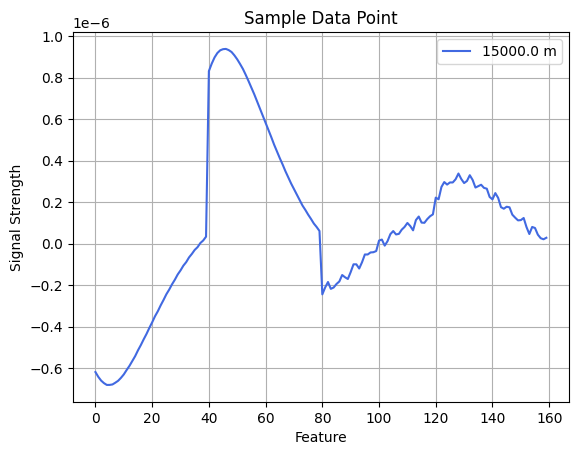

<Figure size 640x480 with 0 Axes>

In [5]:
# Finding which raw/normalized data point is at 15km
index = np.where(yraw == 15000)[0][0]

plt.plot(Xraw[index], c='royalblue', label=f"{yraw[index]} m")
plt.grid()
py.xlabel("Feature")
py.ylabel("Signal Strength")
py.title("Sample Data Point")
plt.legend()
plt.figure()

There's one thing that we have to be careful of before attempting any algorithm on this data - and that is *data snooping*. It is very easy to data snoop on this problem because of the fact that electromagnetic signals get weaker the further you are from the transmitter - think of listening to a radio station and the reception getting weaker the further you are from the city the radio station is in.

Imagine the following: we are given many measurements of an electric field coming from a very powerful emitter. Whatever algorithm we use can directly learn that very strong signals are very close to the transmitter, and weaker signals are far from the emitter. Sounds good right? We train a model and it learns to determine distance from the emitter just based on the strength of the signal coming in. But this does not work.

Imagine next that we test our model on a new data point, but this one comes from a very weak emitter. It will take in a weak signal and predict that we are far from the emitter, even though that may not be the case. In practice, we do not know how strong the emitter is that's putting out the signal. This makes our model useless!

To fix this, we must *normalize* the input data, i.e. change all our data vectors to have norm 1. This removes the strength of the signal from our analysis completely, and forces our method to learn based purely on the shape of the data, not its size.

### What does it mean for our data vectors to have a norm of 1?

In [6]:
def normalize(X):

    normedX = np.zeros_like(X)

    #renormalize
    # First renormalize the first set of real numbers
    normedX[:,0:80] = X[:,0:80] / np.linalg.norm(X[:,0:80], axis=1, keepdims=True).reshape((len(X), 1))

    # Second, renormalize the secnod set of real numbers
    normedX[:,80:160] = X[:,80:160] / np.linalg.norm(X[:,80:160], axis=1, keepdims=True).reshape((len(X), 1))

    return normedX

In [7]:
x_norm=normalize(Xraw)
print(f"Original raw data: {Xraw.shape}")
print(f"Normalized data: {x_norm.shape}")

Original raw data: (1201, 160)
Normalized data: (1201, 160)


<Figure size 640x480 with 0 Axes>

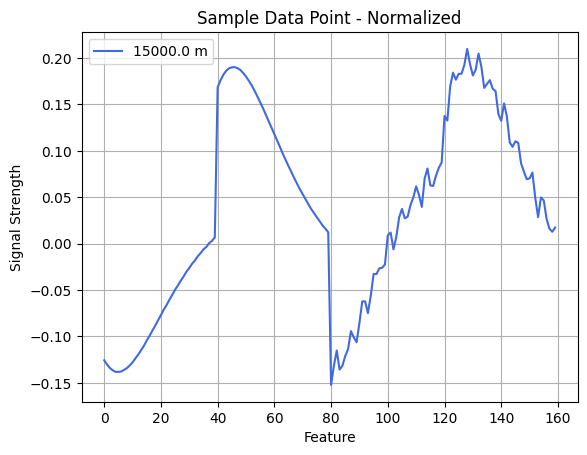

<Figure size 640x480 with 0 Axes>

In [8]:
plt.plot(x_norm[index], c='royalblue', label=f"{yraw[index]} m")
plt.grid()
py.xlabel("Feature")
py.ylabel("Signal Strength")
py.title("Sample Data Point - Normalized")
plt.legend()
plt.figure()

# Naive solution

### Traditional Regression Modeling

![](https://embarc.online/pluginfile.php/32600/mod_page/content/1/review.jpg)

**Recall:**
Still remember what we did in case study 1? Let's re-implement those algorithms in this case study.

What is the first step? Splitting the training and test set right?

The `train_test_split` is a function in `sklearn` for the specific purpose of splitting data into train and test sets.


In [9]:
from sklearn.model_selection import train_test_split
XTrain,XTest, yTrain, yTest = train_test_split(x_norm, yraw, test_size=0.5, shuffle=True,random_state=1)

print(XTrain.shape)
print(XTest.shape)
print(yTrain.shape)
print(yTest.shape)


(600, 160)
(601, 160)
(600,)
(601,)


In [10]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn import linear_model

In [11]:
def train(XTrain,XTest,yTrain,yTest, model_sent: object):
    method = model_sent
    method.fit(XTrain, yTrain)

    y_pred_train=method.predict(XTrain)
    y_pred_test=method.predict(XTest)

    MAE_train=mean_absolute_error(y_pred_train,yTrain)
    MSE_train=mean_squared_error(y_pred_train,yTrain)
    RMSE_train=np.sqrt(mean_squared_error(y_pred_train,yTrain))
    R2_train=r2_score(y_pred_train,yTrain)

    MAE_test=mean_absolute_error(y_pred_test,yTest)
    MSE_test=mean_squared_error(y_pred_test,yTest)
    RMSE_test=np.sqrt(mean_squared_error(y_pred_test,yTest))
    R2_test=r2_score(y_pred_test,yTest)

    return MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test

In [12]:
from tabulate import tabulate
MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test=train(XTrain,XTest,yTrain,yTest, linear_model.LinearRegression())
results=[["Linear regression",MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test]]

In [13]:
print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R2", "Test MAE", "Test MSE", "Test RMSE", "Test R2"],tablefmt="grid"))

+-------------------+----------------+----------------+-----------------+---------------+------------+-------------+-------------+------------+
| Model             |   Training MAE |   Training MSE |   Training RMSE |   Training R2 |   Test MAE |    Test MSE |   Test RMSE |    Test R2 |
+===================+================+================+=================+===============+============+=============+=============+============+
| Linear regression |        10925.1 |    1.92709e+08 |           13882 |     -0.958458 |    52085.1 | 5.87647e+10 |      242414 | -0.0213728 |
+-------------------+----------------+----------------+-----------------+---------------+------------+-------------+-------------+------------+


## **Question 1** **(20 points)**

**Part 1 (10 points)** An easy 10 points since we have done this (almost) before :-)
What do MAE, MSE, RMSE and $R^2$ mean? How are they counted and what is the difference between them? Which is better for describing the performance of your algorithm? Why?

The following are all *performance metrics*. Between them there is no *best* algorithm for evaluating the model's performance but rather using all four while understanding they're individual strengths is the most robust way of interpreting the model's performance:
- **MAE**: Mean Absolute Error - average of the general-error absolute values (actual - predicted). MAE's main strength is that it does not weight the errors, so outliers have a minimal impact. No change to error units.
- **MSE**: Mean Squared Error - conversely MSE is the average of the general-error *squares*. Thus MSE's strength is highly penalizing outlier data. In isolation this sounds like MSE would give you a noisy performance value. But when used in conjunction with MAE, instead you get an idea of how noisy but note the difference in units as MSE squares the error units.
- **RMSE**: Root Mean Squared Error - square root of MSE. It brings the units of MSE back to that of MAE. This normalizing transformation means that RMSE can more accurately be used as a comparison to MAE. If RMSE ~ MAE than the data has uniform, low noise and not major outliers.
- $\mathbf{R^2}$: Coefficient of determination "R Squared" - does not discuss error magnitute at all like MAE, MSE & RMSE. Between 0-1, $R^2$ tells you the data's variance from a regression line fitting of the data, ex: $R^2=0.9$ means 90% of the data's fluctuation is accounted by the model. Thus - similar to MAE, MSE & RMSE - $R^2$ provides insight on outliers. 

**Part 2 (10 points)** Try at least three different methods such as `KNeighborsRegressor(n_neighbors=20)`, `linear_model.Ridge()`, `linear_model.Lasso()`, or `linear_model.BayesianRidge()`. Can you achieve better performance than the previous model? Report your results in the table below. What are your observations? Please analyze the results.

**Analysis**: KNN performs overwhelmingly the best of all the models selected. Notably low `n`-values were preferred. Starting at `n=20` going down to `n=2` the performance improved across all metrics. This is because we have a much higher dimension data for the number of datapoints we have. Due to KNN's curse of dimensionality we would need extreme amounts of data to perform well at the higher `n`-values.

In [14]:
# Import for KNN:
from sklearn.neighbors import KNeighborsRegressor

n = 2
models_dict = {f'KNeighbors (n={n})': KNeighborsRegressor(n_neighbors=n),
               'Ridge': linear_model.Ridge(),
               'Lasso': linear_model.Lasso()}
for name, mod in models_dict.items():
    MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test=train(XTrain,XTest,yTrain,yTest, mod)
    results.append([name,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test])

In [15]:
print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

+-------------------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+--------------+
| Model             |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |    Test MSE |   Test RMSE |     Test R^2 |
+===================+================+================+=================+================+============+=============+=============+==============+
| Linear regression |       10925.1  |    1.92709e+08 |        13882    |      -0.958458 |   52085.1  | 5.87647e+10 |   242414    |   -0.0213728 |
+-------------------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+--------------+
| KNeighbors (n=2)  |        2767.29 |    2.16438e+07 |         4652.29 |       0.921701 |    5368.51 | 5.84804e+07 |     7647.25 |    0.785438  |
+-------------------+----------------+----------------+-----------------+----------------+------------+-------------+-

# Deep Learning

Now that we can move on to deep learning, it's time to train a neural network! Here, we're using a package called PyTorch. It has a lot of built-in tools for coding neural network architechtures and training them. We'll see a few of those in a minute.

![](https://i0.wp.com/semiengineering.com/wp-content/uploads/2018/01/MLvsDL.png?resize=733%2C405&ssl=1)

When training neural networks, we can use different types of hardware and we specify that here. This little bit of code tells PyTorch to figure out whether we're using a GPU or a CPU.

** If you haven't already, to use GPU in the colab: Click Runtime (Upper left corner) → Change runtime type → Hardware accelerator → GPU → Save**. You will then need to re-run all of your cells.


In [16]:
#this is a check to see if a GPU machine that pytorch can use for training
if torch.cuda.is_available():
    print('CUDA available')
    print(torch.cuda.get_device_name(0))
else:
    print('CUDA *not* available')

CUDA available
NVIDIA A100-SXM4-80GB


## **Question 2** **(15 points)**

Before we move on to model training part, Randy 🧙 wants to ask you several questions. Please read the article below and answer the following questions.

https://www.zendesk.com/blog/machine-learning-and-deep-learning/

https://towardsdatascience.com/what-is-a-gpu-and-do-you-need-one-in-deep-learning-718b9597aa0d

**Part 1 (5 points)**

What are the important things that make deep learning different from other machine learning algorithms?

**Part 2 (5 points)**

What are the differences between a CPU and a GPU? Is the performance of GPU always superior to that of CPU? why?  

**Part 3 (5 points)**  

Why are GPUs particularly effective for performing efficient deep learning? Explain.

## **Q2: Answer**
**Part 1**

Deep learning (DL) is an evolution of machine learning (ML). Both are algorithms that use data to learn, but the key difference is how they process and learn from it. For example:

* Machine learning models need human intervention to learn from behaviors and data.
* Deep learning models use neural networks to adjust behaviors and make predictions.

In fact, a deep learning model is able to learn through its own method of computing—a technique that makes it seem like it has its own brain.

**Part 2**

A CPU and a GPU are built for different kinds of work. a CPU has fewer cores, but those cores are powerful and flexible, so it is good for general tasks and step-by-step processing. a GPU has many more cores, and it is designed to do many similar calculations at the same time, so it is much better for highly parallel work.

The performance of a GPU is not always better than a CPU. A GPU is superior mainly when the task can be split into many small operations that run in parallel. But for tasks that are more sequential, need low latency, or need strong single-core performance and quick decision-making, the CPU can be better. So the better one depends on the type of workload, not just on which one is newer or more powerful.

**Part 3**  

GPUs are especially effective for deep learning because deep learning needs a very large number of repeated calculations, and GPUs are very good at doing many operations in parallel. while CPUs can do only a handful of operations at once, GPUs can perform thousands at once. Because of that, training deep learning models can become much faster on a GPU than on a CPU.

Also, frameworks such as TensorFlow and PyTorch can use GPU CUDA cores to speed up deep learning computations. this is a big reason why GPUs are so common in deep learning. Still, if a person is just a beginner, they do not absolutely need a GPU at first. A CPU or free tools like Google Colab can be enough to start learning. So GPUs are very effective for deep learning, but they are most useful when the work becomes more serious and computationally heavy.


#  Neural Network Time

## Important Preliminaries.

Making Neural Networks is more complicated than traditional Machine Learning algorithms we have been using from the `sklearn` package. In order to make building them easier, we use packages like `pytorch` to make building and training them easier. At the same time, `pytorch` is designed to use a programming styple called Object Oriented Programming (OOP), specifically making classes and inheritence, which are software engineering pattern. A common pattern when using `pytorch` is to make a class instance of your network that defines all of the logic while inheriting from a specific `pytorch` class. Therefore, we need to be familiar with Object-Oriented Programming Concepts (OOP).

For those of you who may be unfamiliar with these, here is a brief breakdown of the two. If you are familiar, you may skip to the next section.

### OOP: Classes
1. What is a Class?
  - A class is like a blueprint or template for creating objects in Python.
It defines the attributes (data) and methods (functions) that the objects of that class will have.

  - Creating a Class: To create a class, use the `class` keyword followed by the class name (usually capitalized). Inside the class, you define its attributes (variables) and methods (functions).

Let's take a look at a simple example, and we will go step by step to explain what each part is doing.
  
  ```python
class Dog:
    def __init__(self, name, breed): # this is a special method that says "what attributes/qualities can this class have?
        self.name = name
        self.breed = breed

    def bark(self):
        print(f"{self.name} the {self.breed} says woof!")

```
Let's look at this line by line

```python
class Dog:
```
- This is the manner in which you define a new class and its particular name. Here, we are making a class called `Dog`

```python
class Dog:
  def __init__(self, name, breed):

```
- The next additional line defines what attributes will be associated with this `Dog` object. Here, we want the ability for the `Dog` to have a name and a breed type. We accomplish this by putting these variables in what is called the `__init__()` method. This is a special and reserved function specifically for a class that tells python that the class `Dog` will need these two variables to have an associated `name` and `breed` value when it comes time to instantiate, or make the `Dog`. Remember, the class is like a blueprint of how a certain chunk of code will work, so when it comes time to use this class, we will _instantiate_ it and provide the values for the name and breed, like such:

```python
my_dog = Dog(name="Max", breed="husky")
```
- This makes a new variable `my_dog` that we can use for our own purposes.

You have done this process before! Refer back to Question 1 part 2, when it suggests to use `KNeighborsRegressor(n_neighbors=20)`. In order to use this, we first _instantiate_ the knn model like such:
```python
knn = KNeighborsRegressor(n_neighbors=20)
knn.fit(...)
```
- If we were to look at the source code of the `KNeighborsRegressor`, we will see something similar to:

```python
class KNeighborsRegressor:
  def __init__(self, n_neighbors, other_arg1, other_arg2, ...)
```
- Now, you might notice that weird `self` argument in the `__init__()` function. This is simple python syntax, it refers to the instance of a class. It becomes more clear if we look at more `Dog` code.  

Coming back to our `Dog` example,

  ```python
class Dog:
    def __init__(self, name, breed): # this is a special method that says "what attributes/qualities can this class have?
        self.name = name
        self.breed = breed
```
- The line `self.name = name` _stores_ the name attribute `"Max"` (or whatever name we give when we instantiate the class) into the class itself. This is handy because we may want to define a method within our class that uses that specific name. It is the same logic for `self.breed = breed`.
- If `Dog` is intialized with `my_dog = Dog("max", "husky")`, the `self.name` attribute in the `Dog` class will be stored as `"Max"`, and the `self.breed` attribute will be saved as `"husky"`. To illustrate this, let's _instantiate_ a `Dog` instance and see what the attribute values are

```python
my_dog = Dog(name="Buddy", breed="Husky")
print(my_dog.name) # Output: Max (analogous to self.name, where self = my_dog)
print(my_dog.breed) # Output: Husky (analogous to self.breed, where self = my_dog)
```
- Notice that now `my_dog` is an _instance_ of `Dog`; we can make many different types of dog names and breed combinatioins, and each will have their own unique `name` and `breed` attributes.

The real benefit of doing this is that now we can make methods that still use all the information that is associated with the `Dog` instance. For example, let' make the `bark()` method:

  ```python
class Dog:
    def __init__(self, name, breed): # this is a special method that says "what attributes/qualities can this class have?
        self.name = name
        self.breed = breed

    def bark(self):
        print(f"{self.name} the {self.breed} says woof!")

```
- Notice that in the `bark()` method, we give an argument `self`. This tells the function that the only argument it has access is the particular `Dog` object we are defining, which is represented by `self`, (we put `self` in the `__init__(self, name, breed)` function). So `self` has the attributes `name` and `breed` because we defined it in the `__init__()` method.

To wrap it all together, if we _instantiate_ our `Dog` and use the `bark()` method, what do you think the output will be?

```python
# Creating an instance (object) of the Dog class
my_dog = Dog(name="Max", breed="Husky")
print(my_dog.name) # Output: Max (analogous to self.name, where self = my_dog)
print(my_dog.breed) # Output: Husky (analogous to self.breed, where self = my_dog)
my_dog.bark()  # Output: "Buddy the Husky says woof!"
  ```

In [17]:
class Dog:
  def __init__(self, name, breed):
    self.name = name
    self.breed = breed

  def bark(self):
      print(f"{self.name} the {self.breed} says woof!")

my_dog = Dog("Max", "Husky")
my_dog.bark()


Max the Husky says woof!


### OOP: Inheritance

Now that we have a grasp on what classes are, the second part we need to be familiar with is inheritance. Inheritance in object-oriented programming (OOP) allows a child class (or subclass) to inherit attributes and methods from a parent class (or superclass). It enables code reuse, hierarchy, and modeling relationships between different types of objects. By inheriting from a parent class, the child class gains access to its functionality, promoting efficient and organized code development.

Let's look at an example continuing our `Dog` example.

  ```python
class Dog:
  def __init__(self, name, breed): # this is a special method that says "what attributes/qualities can this class have?
    self.name = name
    self.breed = breed

  def bark(self):
      print(f"{self.name} the {self.breed} says woof!")


class Puppy(Dog):
  def __init__(self, name, breed, age):
    super().__init__(name, breed)
    self.age = age

  def come_here(self):
    print(f"{self.name} the {self.breed} is only {self.age} weeks, too young to listen!!!")

ben = Puppy(name='ben', breed="Golden Retriever", age=10)
ben.come_here() #Outputs: Ben the Golden Retriever is only 10 weeks, too young to listen!!!
ben.bark() # Outputs: Ben the Golden Retriever says woof!

```
Let's break this down step by step:
-  we create a child class called `Puppy` that inherits from the `Dog` class. In other words, we are instructing that `Puppy` will have the same attributes/qualities and functions that `Dog` has. At the same time, the `Puppy` class has an additional attribute called `age`. Since a puppy is a dog, we can write this class to have all the functionality of a `Dog` (like the `bark()` method) without having to explicitly write the `Puppy` class' specific `bark()` function. This makes code more clean and less burdensome overall.
  - Notice now that `Puppy(Dog`) has the `Dog` class in parenthesis. This is the notation to say that `Puppy` is inherting the `Dog` class. We use `super().__init__(name, breed)` to call the constructor of the parent class (`Dog`) and set the name and breed attributes. Think of this as _instantiating_ the `Dog` class within the `Puppy` class like so (just to be clear, below is for illustration, NOT good coding practice):
  ```python
  # this is NOT good code, only for demonstration
  class Puppy:
        def__init__(self, name, breed, age):
          dog = Dog(name, breed)
          self.name = Dog.name
          self.breed = Dog.breed
  ```

  - With the `super(name, breed).__init__()` method, we make a "short-cut" to giving `Puppy` the `name` and `breed` attributes through inheriting those attributes from the `Dog` class. `super` is a specific name given to the Parent (`Dog`) that the child class (`Puppy`) is inherting from.

- Let's take a look at the new function we are defining.
  
  ```python
    def come_here(self):
        print(f"{self.name} the {self.breed} is only {self.age} weeks, too young to listen!!!)
    ```  
  - The `come_here()` method prints a message specific about the puppies, namely that they don't listen!. It's important to note that this method does not belong to the `Dog` class, only to the `Puppy` class.

  ```python
  ben = Puppy(name='Ben', breed="Golden Retriever", age=10)
  ben.come_here() #Outputs: Ben the Golden Retriever is only 10 weeks, too young to listen!!!
  ben.bark() # Outputs: Ben the Golden Retriever says woof!
  ```
  - The key point is this: because `Puppy` is inheriting from the `Dog` class, the `Puppy` class automatically has access to the `bark()` method. As stated before, we don't need to write this method in the `Puppy` class because we are "getting it for free" by inheriting from the `Dog` class.

In summary, the code demonstrates inheritance, where the `Puppy` class inherits attributes and methods from the `Dog` class. By using inheritance, we can create specialized classes (like `Puppy`) that build upon the functionality of a more general class (like `Dog`).


In [18]:
class Dog:
  def __init__(self, name, breed): # this is a special method that says "what attributes/qualities can this class have?
      self.name = name
      self.breed = breed

  def bark(self):
      print(f"{self.name} the {self.breed} says woof!")


class Puppy(Dog):
  def __init__(self, name, breed, age):
    super().__init__(name, breed)
    self.age = age

  def come_here(self):
    print(f"{self.name} the {self.breed} is only {self.age} weeks, too young to listen!!!")

ben = Puppy(name='ben', breed="Golden Retriever", age=10)
ben.come_here() #Outputs: Ben the Golden Retriever is only 10 weeks, too young to listen!!!
ben.bark() # Outputs: Ben the Golden Retriever says woof!

ben the Golden Retriever is only 10 weeks, too young to listen!!!
ben the Golden Retriever says woof!


## Tying it all together.

Now that we are at least familiar with classes and inheritance, it will make understanding how to build neural networks in `pytorch` easier.

We can design a sample neural network architecture here. Let's think about what kind of architecture we want. We know our input is 160 dimensional, so the input to the first layer has to be of size 160. Our output is a single number for a range estimate, so our output has to be 1 dimensional. Everything in between is up to us. And how do we decide what kind of architecture we want? We make it up! At least at first.

This example has 2 layers of size 160 -> 50 -> 1.

In [19]:
import torch.nn as nn
class mynetwork_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,50),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x

Let's go over how this network is structured:

```python
class mynetwork_1(nn.Module):
    def __init__(self):
        super().__init__()

```
This creates a class `mynetwork_1`, in which it is inheriting from a module called `torch.nn.Module`. The `torch.nn.Module` is a class from the `pytorch` library that is specifically designed to be inherited from in order to make custom networks in classes easier to build. Notice we are using the `super().__init__()` method to inherit all the functionality that `nn.Module` has.

```python
class mynetwork_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,50),
            nn.Linear(50, 1)
        )
```
The next line defines a neural network blueprint. It is a special kind of class, `nn.Sequential`, which in simple terms is a container for holding specific layer types. The specific layers we will use are:
1. a Linear layer that has an input size of 160 and an output size of 50, and
2. another Linear layer that has an input size of 50 and an output size of 1.

This is the heart of our neural network, the 2 layers are designed such that when they are passed our raw data, they will outupt a singular value. We instantiate them in order within the `nn.Sequential` class, so that we can treat the two layers as one main pipeline. The output of the first linear layer will automatically be passed as input to the second linear layer, and the output of the second linear layer will be returned for us.

Let's look at our one specific function we have defined

```python
    def forward(self, x):
        x = self.structure(x)
        return x
```
This function is **required** for every class you create when inheriting from `torch.nn.Module`.  It defines the flow of the data for your network. Speficically in our network and our simple case, it defines that an input, `x`, which will be our raw data, is passed through the `self.structure` attribute, which is our container for our linear layers. It returns the final ouput, which will be a scalar value.

And that's it for defining a neural network! The keys are
  1. Inherit from `torch.nn.Module` and run the `super().__init__()` within the `def __init__(self)` method
  2. Define your layers, typically in the `nn.Sequential` object
  3. Define the `forward(self, x)` function that tells how the final output will be made.  

Let's make another another network to compare how a different architecture choice will affect the model.

In [20]:
class mynetwork_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,50),
            nn.Sigmoid(),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x

## **Question 3** **(5 points)**

**Part 1 (5 points)**

Comparing the two network structures above, what is the difference between them? In other words, what is `nn.Sigmoid()`, why do we need it? Can both networks perform nonlinearity? why?

**ANSWER**: NO! The first NN only has two linear layers so it cannot perform nonlinearity. `nn.Sigmoid()` is a nonlinear activation function, which - when placed between layers - introduces a non-linear mapping to the NN's hidden layer allowing the NN to perform nonlinearity and enabling higher complexity than just straight lines.

Next we need to choose some training settings:

`batch size`

`number of epochs`

`learning rate`

`criterion (loss function)`

## **Question 4** **(10 points)**

Randy 🧙 wants you to know what they are, rather than just turning the numbers. Please read the article below and answer the following questions.

https://blog.paperspace.com/intro-to-optimization-in-deep-learning-gradient-descent/

https://towardsdatascience.com/what-are-hyperparameters-and-how-to-tune-the-hyperparameters-in-a-deep-neural-network-d0604917584a

**Part 1 (5 points)**

Explain how neural network optimize its parameters (weights) using gradient descent. Does it always guarantee to find the global minima? why?

**Part 1 (5 points)**

What are `batch size`, `number of epochs`, `learning rate`, `criterion (loss function)`? How do they impact the optimization of neural networks?

## **Q4: Answer** 
**Part 1**

Neural networks optimize their weights by using gradient descent. What happens is that the network first makes a prediction, then calculates the loss, which shows how wrong that prediction is. After that, it finds the gradient, which tells it which direction will reduce the loss the fastest. Then it updates the weights little by little and keeps repeating this process during training. So basically, the model is trying to move step by step toward lower error.

But no, gradient descent does not always guarantee that the network will find the global minimum. The article explains that deep learning problems usually have very complicated loss surfaces, so the model can get stuck in a local minimum or a saddle point instead of reaching the absolute best point. That is why training a neural network is not just about turning the numbers, because the path of optimization can be messy and not perfect.

Also, the learning rate matters a lot here. If the learning rate is too big, the model can overshoot the minimum and keep bouncing around. If it is too small, learning becomes very slow and it may still get stuck. So gradient descent helps the network improve its weights, but it does not promise the perfect final answer every time.

**Part 2**

`batch size` means how many training examples the network uses before updating the weights one time. In the article, mini-batch size is explained as the number of sub-samples given to the network before a parameter update happens. A small batch size updates more often, while a larger batch size is usually more stable but also needs more memory.

`number of epochs` means how many times the whole training dataset is passed through the network. If you use more epochs, the network gets more chances to learn. But if you use too many, the model can start to overfit, which means it learns the training data too much and does worse on new data. The article says a common sign is when training accuracy keeps going up but validation accuracy starts going down.

`learning rate` is how big of a step the network takes when updating its weights. This one is super important. If it is too high, training may become unstable and may not converge. If it is too low, training becomes slow, even if it is smoother. So the learning rate strongly affects how well and how fast optimization works.

`criterion (loss function)` is the function that measures how wrong the network’s prediction is. The neural network tries to minimize this value during training. So in simple words, the loss function is what tells the model, this prediction is bad or this one is better. Gradient descent uses this loss to decide how to change the weights

### **Traning Network**

Now you know what the hyperparameters are. As we might guess, the more epochs we decide to use, the longer it will take and (hopefully) the better accuracy we get. We'll start with 500 in this example. We also have to specify our criterion, or our Loss function. The standard one is to use mean squared error (MSE), which is the standard loss function.

### Now is the time where you can switch to a GPU if you would like (refer to beginning of notebook for how to do that)

### One last `pytorch` note:

Remember when we trained `sklearn` models that the models expected the input be a `numpy.ndarray` object? With `pytorch`, we can't use those `numpy` objects, they need to be another type of array called a `torch.Tensor`. The term `Tensor` is analagous to the `ndarray`, but is is specialized for `pytorch`. So in the code below, you will see many times we are converting our raw data that we downloaded from the url, which is a `numpy.ndarray` into something else, specifically as a `torch.Tensor` object to be compatable with our neural network defined above.  

In [21]:
torch.manual_seed(50) # this makes results reproducable

# If using a GPU, use option 1, if not, use option 2.
 # (If we using GPU, we need to place the class we defined to be put onto the GPU)

# 1
# this says " if there is a GPU, make sure my model can be used on the GPU"
# "if a GPU is not available, then use the CPU"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_1 = mynetwork_1().to(DEVICE)
model_2 = mynetwork_2().to(DEVICE)


# 2
#model = mynetwork()

#training settings
batch_size = 100
num_epochs = 500
learning_rate = 1e-3
criterion = nn.MSELoss()

# print interval during the training
print_interval=20

# what this does is save the actual gpu device to a variable.
# in the next cell, we will use this `device` variable
# to say "make my data compatable with my model if it is on the GPU"


In [22]:
def train(training_inputs, training_outputs, network, epochs, learning_rate,
          batch_size, loss_function, print_interval):
  """
  Trains a neural network model using the specified parameters.

  Args:
      training_inputs (numpy.ndarray): Input data (features) for training.
      training_outputs (numpy.ndarray): Target outputs (labels) for training.
      network (torch.nn.Module): The neural network model to be trained.
      epochs (int): Number of training epochs.
      learning_rate (float): Learning rate for optimization.
      batch_size (int): Batch size for mini-batch gradient descent.
      loss_function (torch.nn.Module): Loss function for optimization.
      print_interval (int): Interval for printing training progress.

  Returns:
      None
  """

  # Step 1: convert numpy data to tensor data for pytorch. Feeding numpy data to
  # a pytorch model will create errors.

  # Notice we are doing two things here
  # 1. We convert both the input and target numpy arrays into a torch.Tensor
  # using the convenient torch.from_numpy() function.
  # PyTorch models don't work with numpy data!!
  # 2. We then are wrapping this tensor into a TensorDataset class. We will skip
  # the details of this, but this is needed for the next line.
  # Just know that whenever your input is originally a numpy array,
  # you will follow this pattern to get it set up correctly for you pytorch model
  train_dataset = torch.utils.data.TensorDataset(torch.from_numpy(training_inputs).float(),
                                                 torch.from_numpy(training_outputs).float())

  # we wrap the TensorDataset into what is called a DataLoader.
  # Recall in sklearn models, we pass the entire training dataset at once into the
  # model. With neural networks, we instead pass a chunk/batch of data into the model,
  # get its outputs, and update the parameters based on this chunk. Then we pass
  # the next chunk and repeat until a desired number of iterations.

  # a dataloader is a special pytorch class that formats the data to create
  # these chunks so that in your training loop, you can pass a chunk in one at a time,
  # update your parameters based on the chunck, and repeat.
  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                             shuffle=True)

  # The optimizer is the object that will update the parameters of your model,
  # here we need to instantiate it first. The first argument, `network.parameters()`,
  # says "here are the parameters you will be updating".
  optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate, weight_decay=1e-5)
  track_losses = np.zeros(epochs)

  start = time.time()

  # here is the main part of the training procedure.
  for epoch in range(1, epochs+1):

      # the following line says "loop through all the chunks that exist in my data"
      # each chunk is a tuple object, the first argument is the data (assigned
      # to X), the second argument is the target (assigned to y)
      for batch_idx, (X, y) in enumerate(train_loader):
          # grab the x's for this batch
          data = X

          # we have placed our model onto the gpu; we must also ensure that the
          # inputs to the model are also compatable with the gpu, so we manually tell
          # pytorch to place our `data` variable onto the GPU machine so that
          # our model (also on the GPU) can work with it.
          data = data.to(DEVICE)

          # find the predictions f(x) for this batch using the forward() method
          output = network.forward(data)

          # find the loss. This calculates MSE using the pytorch version of MSE
          # ('criterion' in previous cell)
          loss = loss_function(output, y.view([-1, 1]).to(DEVICE))

          # compute the gradient and update the network parameters
          # the gradient are the values calculated from how well the model
          # predicted the target for this batch/chunk, and they will be added
          # to the model parameters so that the model will perform better on the
          # next chunk of data.

          # this says make all gradients equal to 0 (if you don't, they will
          # include the gradients of the previous chunk, so you are accidentally
          # adding with values that do not apply to the current chunk,
          # which you do not want)
          optimizer.zero_grad()

          # "calculate the gradients for the model parameters"
          loss.backward()

          # "add the gradients to the model parameters"
          optimizer.step()

      # housekeeping - keep track of our losses and print them as we go
      training_loss = loss.item()**.5
      track_losses[epoch-1] = training_loss
      if epoch % print_interval == 0:
          print('epoch: %4d training loss:%10.3e time:%7.1f'%(epoch, training_loss, time.time()-start))

  return network, track_losses

In [23]:
network_1, losses = train(XTrain, yTrain, model_1, num_epochs, learning_rate, batch_size, criterion, print_interval)
network_2, losses = train(XTrain, yTrain, model_2, num_epochs, learning_rate, batch_size, criterion, print_interval)

epoch:   20 training loss: 4.352e+04 time:    0.8
epoch:   40 training loss: 4.311e+04 time:    1.0
epoch:   60 training loss: 4.254e+04 time:    1.2
epoch:   80 training loss: 4.564e+04 time:    1.4
epoch:  100 training loss: 4.338e+04 time:    1.6
epoch:  120 training loss: 4.120e+04 time:    1.8
epoch:  140 training loss: 4.542e+04 time:    2.0
epoch:  160 training loss: 4.226e+04 time:    2.3
epoch:  180 training loss: 4.191e+04 time:    2.5
epoch:  200 training loss: 4.350e+04 time:    2.7
epoch:  220 training loss: 4.272e+04 time:    2.9
epoch:  240 training loss: 4.434e+04 time:    3.1
epoch:  260 training loss: 4.217e+04 time:    3.3
epoch:  280 training loss: 4.516e+04 time:    3.6
epoch:  300 training loss: 4.234e+04 time:    3.8
epoch:  320 training loss: 4.353e+04 time:    4.0
epoch:  340 training loss: 4.416e+04 time:    4.2
epoch:  360 training loss: 4.318e+04 time:    4.4
epoch:  380 training loss: 4.250e+04 time:    4.6
epoch:  400 training loss: 4.079e+04 time:    4.8


### **Evaluation**

Now, we need to evaluate our network.

In [24]:
def model_eva(XTrain,XTest,yTrain,yTest,model):
  """
  Evaluates a machine learning model's performance on training and test data.

  Args:
    XTrain (numpy.ndarray): Training input features.
    XTest (numpy.ndarray): Test input features.
    yTrain (numpy.ndarray): Actual training target values.
    yTest (numpy.ndarray): Actual test target values.
    model (torch.nn.Module): Trained PyTorch model.

  Returns:
    tuple: A tuple containing the following evaluation metrics:
    - MAE_train (float): Mean Absolute Error on the training set.
    - MSE_train (float): Mean Squared Error on the training set.
    - RMSE_train (float): Root Mean Squared Error on the training set.
    - R2_train (float): R-squared (coefficient of determination) on the training set.
    - MAE_test (float): Mean Absolute Error on the test set.
    - MSE_test (float): Mean Squared Error on the test set.
    - RMSE_test (float): Root Mean Squared Error on the test set.
    - R2_test (float): R-squared (coefficient of determination) on the test set.
  """
  # since we have placed our model onto the gpu, we must also ensure that the
  # inputs to the model are also compatable with the gpu, so we manually tell
  # pytorch to make a new Tensor from our numpy array, and add the .cuda() to
  # ensure that this new tensor is GPU-compatable.
  XTrain_th = torch.from_numpy(XTrain).float().to(DEVICE)
  XTest_th = torch.from_numpy(XTest).float().to(DEVICE)
  #yTrain_th=torch.Tensor(yTrain).cuda()
  #yTest_th=torch.Tensor(yTest).cuda()

  # get predictions on the training set
  yTrain_pred = model.forward(XTrain_th)

  # since we are using sklearn functions, these must be numpy arrays,
  # so we manually change them from torch.Tensors to np.ndarray's
  yTrain_pred_np = yTrain_pred.cpu().detach().numpy().reshape(-1)

  yTest_pred = model.forward(XTest_th)
  yTest_pred_np = yTest_pred.cpu().detach().numpy().reshape(-1)

  MAE_train=mean_absolute_error(yTrain_pred_np,yTrain)
  MSE_train=mean_squared_error(yTrain_pred_np,yTrain)
  RMSE_train=np.sqrt(mean_squared_error(yTrain_pred_np,yTrain))
  R2_train=r2_score(yTrain_pred_np,yTrain)

  MAE_test=mean_absolute_error(yTest_pred_np,yTest)
  MSE_test=mean_squared_error(yTest_pred_np,yTest)
  RMSE_test=np.sqrt(mean_squared_error(yTest_pred_np,yTest))
  R2_test=r2_score(yTest_pred_np,yTest)

  return MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test

In [25]:
MAE_train_nn1,MSE_train_nn1,RMSE_train_nn1,R2_train_nn1,MAE_test_nn1,MSE_test_nn1,RMSE_test_nn1,R2_test_nn1 = model_eva(XTrain,XTest,yTrain,yTest,network_1)
MAE_train_nn2,MSE_train_nn2,RMSE_train_nn2,R2_train_nn2,MAE_test_nn2,MSE_test_nn2,RMSE_test_nn2,R2_test_nn2 = model_eva(XTrain,XTest,yTrain,yTest,network_2)

results.append(["NN_1",MAE_train_nn1,MSE_train_nn1,RMSE_train_nn1,R2_train_nn1,MAE_test_nn1,MSE_test_nn1,RMSE_test_nn1,R2_test_nn1])
results.append(["NN_2",MAE_train_nn2,MSE_train_nn2,RMSE_train_nn2,R2_train_nn2,MAE_test_nn2,MSE_test_nn2,RMSE_test_nn2,R2_test_nn2])


In [26]:
print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

+-------------------+----------------+----------------+-----------------+-----------------+------------+-------------+-------------+-----------------+
| Model             |   Training MAE |   Training MSE |   Training RMSE |    Training R^2 |   Test MAE |    Test MSE |   Test RMSE |        Test R^2 |
+===================+================+================+=================+=================+============+=============+=============+=================+
| Linear regression |       10925.1  |    1.92709e+08 |        13882    |    -0.958458    |   52085.1  | 5.87647e+10 |   242414    |    -0.0213728   |
+-------------------+----------------+----------------+-----------------+-----------------+------------+-------------+-------------+-----------------+
| KNeighbors (n=2)  |        2767.29 |    2.16438e+07 |         4652.29 |     0.921701    |    5368.51 | 5.84804e+07 |     7647.25 |     0.785438    |
+-------------------+----------------+----------------+-----------------+-----------------+---

This result does not seem to be very good, so let's try increasing the number of network layers.

In [27]:
class mynetwork_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,100),
            nn.LeakyReLU(), # this is a different type of activation function
            nn.Linear(100,80),
            nn.LeakyReLU(), # it has a similar affect as nn.Sigmoid()
            nn.Linear(80,50),
            nn.LeakyReLU(), # But what is the key difference?
            nn.Linear(50,1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x

In [28]:
model_3 = mynetwork_3().to(DEVICE)
network_3, losses = train(XTrain, yTrain, model_3, num_epochs, learning_rate, batch_size, criterion, print_interval)

epoch:   20 training loss: 4.229e+04 time:    0.3
epoch:   40 training loss: 2.494e+04 time:    0.6
epoch:   60 training loss: 1.907e+04 time:    0.8
epoch:   80 training loss: 1.649e+04 time:    1.1
epoch:  100 training loss: 1.264e+04 time:    1.4
epoch:  120 training loss: 1.135e+04 time:    1.6
epoch:  140 training loss: 8.795e+03 time:    1.9
epoch:  160 training loss: 7.032e+03 time:    2.2
epoch:  180 training loss: 7.253e+03 time:    2.4
epoch:  200 training loss: 5.819e+03 time:    2.7
epoch:  220 training loss: 5.139e+03 time:    3.0
epoch:  240 training loss: 4.819e+03 time:    3.2
epoch:  260 training loss: 4.438e+03 time:    3.5
epoch:  280 training loss: 4.658e+03 time:    3.8
epoch:  300 training loss: 3.736e+03 time:    4.1
epoch:  320 training loss: 3.721e+03 time:    4.3
epoch:  340 training loss: 3.629e+03 time:    4.6
epoch:  360 training loss: 3.767e+03 time:    4.9
epoch:  380 training loss: 3.395e+03 time:    5.1
epoch:  400 training loss: 3.189e+03 time:    5.4


We can plot the training loss by epochs.

<Figure size 640x480 with 0 Axes>

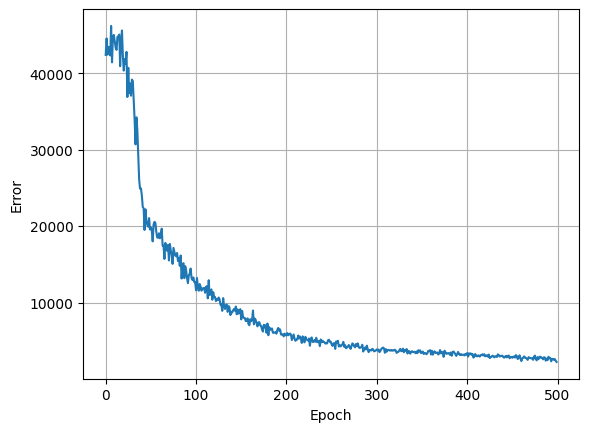

<Figure size 640x480 with 0 Axes>

In [29]:
plt.plot(losses)
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Error")

plt.figure()

In [30]:
MAE_train_nn3,MSE_train_nn3,RMSE_train_nn3,R2_train_nn3,MAE_test_nn3,MSE_test_nn3,RMSE_test_nn3,R2_test_nn3 = model_eva(XTrain,XTest,yTrain,yTest,network_3)
results.append(["NN_3",MAE_train_nn3,MSE_train_nn3,RMSE_train_nn3,R2_train_nn3,MAE_test_nn3,MSE_test_nn3,RMSE_test_nn3,R2_test_nn3])
print (tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

+-------------------+----------------+----------------+-----------------+-----------------+------------+-------------+-------------+-----------------+
| Model             |   Training MAE |   Training MSE |   Training RMSE |    Training R^2 |   Test MAE |    Test MSE |   Test RMSE |        Test R^2 |
+===================+================+================+=================+=================+============+=============+=============+=================+
| Linear regression |       10925.1  |    1.92709e+08 |        13882    |    -0.958458    |   52085.1  | 5.87647e+10 |   242414    |    -0.0213728   |
+-------------------+----------------+----------------+-----------------+-----------------+------------+-------------+-------------+-----------------+
| KNeighbors (n=2)  |        2767.29 |    2.16438e+07 |         4652.29 |     0.921701    |    5368.51 | 5.84804e+07 |     7647.25 |     0.785438    |
+-------------------+----------------+----------------+-----------------+-----------------+---

![](https://media.makeameme.org/created/its-magic.jpg)

Look at this result! Now you know the power of neural networks! But that's not the limit of it. Now it's time to design your own network.

## **Question 5** **(10 points)**

**Part 1 (5 points)**: You should notice that we have changed the activation function from `nn.Sigmoid()` to `nn.LeakyReLU()`. Please explain the difference between `nn.Sigmoid()`, `nn.LeakyReLU()` and `nn.ReLU()`. What are their advantages and disadvantages respectively.

- **Sigmoid**: $f(x) = \frac{1}{1+e^{-x}}$ - primarily excels at classification problems because it is bounds all values to 0-1 - "either this or that". Dissadvantages are that Sigmoid does not let negative values through the NN. It has a "vanishing gradient" problem because at the extremes of sigmoid you loose information on what the input magnitude was, because it got capped at 0 or 1 respectively.

- **ReLU**: $f(x) = max(0,x)$ - pros are simplicity and computational efficiency making ReLU seem to be the **"go-to" activation function** for NNs. issues are that there is a discontinuity at 0, meaning you cannot take the derivatives at zero. Also you cannot differentiate between negative inputs since they all become zero - so ReLU minimizes a "vanishing gradient" effect because the phenomenon only happens on one side.

- **LeakyReLU**: $f(x) = max(\alpha x,x)$ : $\alpha << 1$ - pros are similar to those of ReLU. The advantage it has over ReLU is that it does not cap any values on either side of zero, so there is no "vanishing gradient" effect with LeakyReLU. Downsides are similarly that there is a discontinuity at 0.

**Part 2 (5 points)**: Replace the activation functions in `mynetwork_3()` with `nn.Sigmoid()` and `nn.ReLU()` and report the results in the following table. Which activation function performs best and why?

**Answer**: Based on the tabulated results `ReLU` performed better than `Sigmoid`, though it was slightly worse comparatively to the original `mynetwork_3()` (`NN_3` in the table). As mentioned, the original `NN_3` network used `LeakyReLU` as its activation function of choice. Since `LeakyReLU` is an improvement over `ReLU`, having no "vanishing gradient". This means that our data likes to have feedback on the negative side.

In [31]:
# Creating NN for Question 5, adapting previous sample code for expandability:
class mynetwork_3_Q5(nn.Module):
    def __init__(self, activation_function):
        super().__init__()
        self.activation = activation_function
        self.structure = nn.Sequential(
            nn.Linear(160,100),
            self.activation,
            nn.Linear(100,80),
            self.activation,
            nn.Linear(80,50),
            self.activation,
            nn.Linear(50,1)
        )

    # Required forward() fcn, don't fully understand why it is important
    def forward(self, x):
        x = self.structure(x)
        return x

# Sigmoid and ReLU dict to use when creating the NNs and formatting the results entry
models_dict = {'NN_3_sigmoid'   : nn.Sigmoid(),
               'NN_3_relu'      : nn.ReLU()}

# Check if Sigmoid and ReLU entries are in results to remove before re-running
if any(str(list(models_dict.keys())[0]) in sublist for sublist in results):
    results = results[:-2]

# Creating, training, evaluating and adding Sigmoid and ReLU to results
for name, this_fcn in models_dict.items():
    # NN model instantiation & training:
    this_model = mynetwork_3_Q5(activation_function=this_fcn).to(DEVICE)
    this_model, losses = train(XTrain, yTrain, this_model, num_epochs, learning_rate, batch_size, criterion, print_interval)

    # Evaluate and append to growing results table:
    MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test = model_eva(XTrain,XTest,yTrain,yTest,this_model)
    results.append([name,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test])
    
print (tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))


epoch:   20 training loss: 4.216e+04 time:    0.3
epoch:   40 training loss: 4.096e+04 time:    0.5
epoch:   60 training loss: 4.416e+04 time:    0.8
epoch:   80 training loss: 4.418e+04 time:    1.1
epoch:  100 training loss: 4.319e+04 time:    1.3
epoch:  120 training loss: 4.064e+04 time:    1.6
epoch:  140 training loss: 4.376e+04 time:    1.9
epoch:  160 training loss: 4.383e+04 time:    2.1
epoch:  180 training loss: 4.385e+04 time:    2.4
epoch:  200 training loss: 4.287e+04 time:    2.7
epoch:  220 training loss: 4.298e+04 time:    2.9
epoch:  240 training loss: 4.336e+04 time:    3.2
epoch:  260 training loss: 4.328e+04 time:    3.5
epoch:  280 training loss: 4.222e+04 time:    3.7
epoch:  300 training loss: 4.270e+04 time:    4.0
epoch:  320 training loss: 4.330e+04 time:    4.3
epoch:  340 training loss: 4.737e+04 time:    4.5
epoch:  360 training loss: 4.235e+04 time:    4.8
epoch:  380 training loss: 4.289e+04 time:    5.1
epoch:  400 training loss: 4.320e+04 time:    5.3


## **Question 6** **(10 points)**

**Part 1 (10 points)**

Design at least 3 different neural network structures and train them (e.g., different number of network layers, different number of neurons, different activation functions, etc.). Please report your results, you should be able to design one that is superior to `NN_3`. (Hint: You may need to tune your hyperparameters (`batch size`, `number of epochs`, `learning rate`) to get higher performance.)


## **Q6: Answer**

For this question, i tried 3 different neural network structures by changing the number of layers, number of neurons, activation functions, and also the hyperparameters. Since NN_3 already had strong performance with a test MAE of about 2502.83 and test R² of about 0.9645, I tried to make the new networks a little deeper and also tuned the batch size, number of epochs, and learning rate.

"Your NN 1 (ReLU)" is a simpler deep network with two hidden layers and ReLU activation. i used it to see if a basic deeper structure could already improve the result over NN_3.

"Your NN 2 (LeakyReLU)" uses LeakyReLU and has more neurons. This one is closer to NN_3, but a little wider and trained longer. i expected this one to perform better because LeakyReLU worked well earlier.

"Your NN 3 (Deep)" is the deepest one, with four hidden layers and a smaller learning rate. I used a lower learning rate because deeper networks can be harder to train, and I wanted the updates to be more stable.

From these experiments, the best model is "Your NN 2 (LeakyReLU)" with the lowest test MAE and the highest test R². it means the new structure and hyperparameter choice worked better for this problem.


In [32]:
class mynetwork_q6_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x


class mynetwork_q6_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,200),
            nn.LeakyReLU(),
            nn.Linear(200,100),
            nn.LeakyReLU(),
            nn.Linear(100,50),
            nn.LeakyReLU(),
            nn.Linear(50,1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x


class mynetwork_q6_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,256),
            nn.LeakyReLU(),
            nn.Linear(256,128),
            nn.LeakyReLU(),
            nn.Linear(128,64),
            nn.LeakyReLU(),
            nn.Linear(64,32),
            nn.LeakyReLU(),
            nn.Linear(32,1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x

In [33]:
# if any("Your NN 1" in str(sublist) for sublist in results):
#     results = results[:-3]

In [34]:
torch.manual_seed(50)

model_q6_1 = mynetwork_q6_1().to(DEVICE)
model_q6_2 = mynetwork_q6_2().to(DEVICE)
model_q6_3 = mynetwork_q6_3().to(DEVICE)

criterion = nn.MSELoss()
print_interval = 20

In [35]:
batch_size = 100
num_epochs = 500
learning_rate = 1e-3

network_q6_1, losses_q6_1 = train(XTrain, yTrain, model_q6_1, num_epochs, learning_rate, batch_size, criterion, print_interval)

epoch:   20 training loss: 4.495e+04 time:    0.3
epoch:   40 training loss: 4.353e+04 time:    0.5
epoch:   60 training loss: 3.872e+04 time:    0.7
epoch:   80 training loss: 3.173e+04 time:    1.0
epoch:  100 training loss: 2.504e+04 time:    1.2
epoch:  120 training loss: 2.272e+04 time:    1.5
epoch:  140 training loss: 2.104e+04 time:    1.7
epoch:  160 training loss: 1.909e+04 time:    2.0
epoch:  180 training loss: 1.944e+04 time:    2.2
epoch:  200 training loss: 1.854e+04 time:    2.4
epoch:  220 training loss: 1.715e+04 time:    2.7
epoch:  240 training loss: 1.557e+04 time:    2.9
epoch:  260 training loss: 1.553e+04 time:    3.2
epoch:  280 training loss: 1.556e+04 time:    3.4
epoch:  300 training loss: 1.465e+04 time:    3.7
epoch:  320 training loss: 1.289e+04 time:    3.9
epoch:  340 training loss: 1.267e+04 time:    4.2
epoch:  360 training loss: 1.205e+04 time:    4.4
epoch:  380 training loss: 1.130e+04 time:    4.7
epoch:  400 training loss: 1.036e+04 time:    4.9


In [36]:
batch_size = 50
num_epochs = 1000
learning_rate = 1e-3

network_q6_2, losses_q6_2 = train(XTrain, yTrain, model_q6_2, num_epochs, learning_rate, batch_size, criterion, print_interval)

epoch:   20 training loss: 1.932e+04 time:    0.5
epoch:   40 training loss: 1.599e+04 time:    1.0
epoch:   60 training loss: 1.248e+04 time:    1.4
epoch:   80 training loss: 7.483e+03 time:    1.9
epoch:  100 training loss: 5.321e+03 time:    2.4
epoch:  120 training loss: 4.356e+03 time:    2.9
epoch:  140 training loss: 5.091e+03 time:    3.3
epoch:  160 training loss: 4.238e+03 time:    3.8
epoch:  180 training loss: 3.253e+03 time:    4.3
epoch:  200 training loss: 3.383e+03 time:    4.7
epoch:  220 training loss: 3.217e+03 time:    5.2
epoch:  240 training loss: 3.072e+03 time:    5.7
epoch:  260 training loss: 3.097e+03 time:    6.2
epoch:  280 training loss: 2.696e+03 time:    6.6
epoch:  300 training loss: 2.100e+03 time:    7.1
epoch:  320 training loss: 2.347e+03 time:    7.6
epoch:  340 training loss: 2.295e+03 time:    8.1
epoch:  360 training loss: 1.721e+03 time:    8.6
epoch:  380 training loss: 1.868e+03 time:    9.0
epoch:  400 training loss: 1.433e+03 time:    9.5


In [37]:
batch_size = 50
num_epochs = 1000
learning_rate = 1e-4

network_q6_3, losses_q6_3 = train(XTrain, yTrain, model_q6_3, num_epochs, learning_rate, batch_size, criterion, print_interval)

epoch:   20 training loss: 4.515e+04 time:    0.5
epoch:   40 training loss: 4.580e+04 time:    1.0
epoch:   60 training loss: 3.765e+04 time:    1.6
epoch:   80 training loss: 2.457e+04 time:    2.1
epoch:  100 training loss: 1.990e+04 time:    2.6
epoch:  120 training loss: 1.748e+04 time:    3.2
epoch:  140 training loss: 1.797e+04 time:    3.7
epoch:  160 training loss: 1.724e+04 time:    4.2
epoch:  180 training loss: 1.569e+04 time:    4.7
epoch:  200 training loss: 1.318e+04 time:    5.2
epoch:  220 training loss: 1.423e+04 time:    5.8
epoch:  240 training loss: 1.125e+04 time:    6.3
epoch:  260 training loss: 1.126e+04 time:    6.8
epoch:  280 training loss: 1.073e+04 time:    7.3
epoch:  300 training loss: 1.006e+04 time:    7.8
epoch:  320 training loss: 1.010e+04 time:    8.3
epoch:  340 training loss: 8.323e+03 time:    8.8
epoch:  360 training loss: 7.029e+03 time:    9.4
epoch:  380 training loss: 6.685e+03 time:    9.9
epoch:  400 training loss: 6.537e+03 time:   10.4


In [38]:
MAE_train_q6_1,MSE_train_q6_1,RMSE_train_q6_1,R2_train_q6_1,MAE_test_q6_1,MSE_test_q6_1,RMSE_test_q6_1,R2_test_q6_1 = model_eva(XTrain,XTest,yTrain,yTest,network_q6_1)
MAE_train_q6_2,MSE_train_q6_2,RMSE_train_q6_2,R2_train_q6_2,MAE_test_q6_2,MSE_test_q6_2,RMSE_test_q6_2,R2_test_q6_2 = model_eva(XTrain,XTest,yTrain,yTest,network_q6_2)
MAE_train_q6_3,MSE_train_q6_3,RMSE_train_q6_3,R2_train_q6_3,MAE_test_q6_3,MSE_test_q6_3,RMSE_test_q6_3,R2_test_q6_3 = model_eva(XTrain,XTest,yTrain,yTest,network_q6_3)

results.append(["Your NN 1 (ReLU)",MAE_train_q6_1,MSE_train_q6_1,RMSE_train_q6_1,R2_train_q6_1,MAE_test_q6_1,MSE_test_q6_1,RMSE_test_q6_1,R2_test_q6_1])
results.append(["Your NN 2 (Leaky ReLU)",MAE_train_q6_2,MSE_train_q6_2,RMSE_train_q6_2,R2_train_q6_2,MAE_test_q6_2,MSE_test_q6_2,RMSE_test_q6_2,R2_test_q6_2])
results.append(["Your NN 3 (Deep)",MAE_train_q6_3,MSE_train_q6_3,RMSE_train_q6_3,R2_train_q6_3,MAE_test_q6_3,MSE_test_q6_3,RMSE_test_q6_3,R2_test_q6_3])

print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

+------------------------+----------------+-----------------+-----------------+-----------------+------------+------------------+-------------+-----------------+
| Model                  |   Training MAE |    Training MSE |   Training RMSE |    Training R^2 |   Test MAE |         Test MSE |   Test RMSE |        Test R^2 |
+========================+================+=================+=================+=================+============+==================+=============+=================+
| Linear regression      |     10925.1    |     1.92709e+08 |       13882     |    -0.958458    |  52085.1   |      5.87647e+10 |  242414     |    -0.0213728   |
+------------------------+----------------+-----------------+-----------------+-----------------+------------+------------------+-------------+-----------------+
| KNeighbors (n=2)       |      2767.29   |     2.16438e+07 |        4652.29  |     0.921701    |   5368.51  |      5.84804e+07 |    7647.25  |     0.785438    |
+------------------------+--

In [39]:
# results.append(["Your NN 1"," "," "," "," "," "," "," "," "])
# results.append(["Your NN 2"," "," "," "," "," "," "," "," "])
# results.append(["Your NN 3"," "," "," "," "," "," "," "," "])
# print (tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

# Deep Learning + Feature Engineering

Now you know what deep learning is. Can't we do some feature engineering to improve its performance?

![?](https://www.mememaker.net/static/images/memes/4751028.jpg)

Let's take a look at our data points again! Here's what an electric field measurement looks like when the transmitter is 15km away, i.e., at a range of 15 km.

<Figure size 640x480 with 0 Axes>

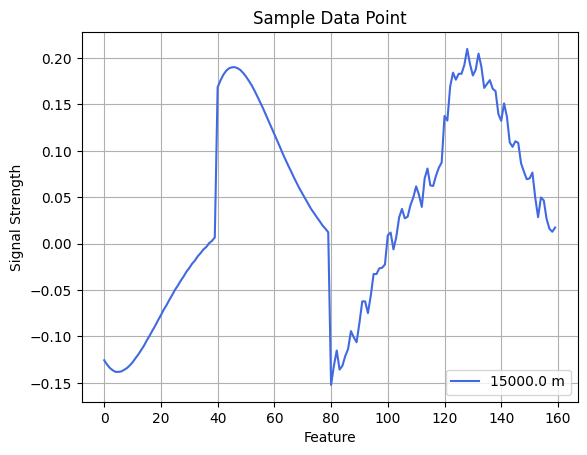

<Figure size 640x480 with 0 Axes>

In [40]:
# Finding which training data point is at 15km
index = np.where(yTrain == 15000)[0][0]

# Training data is shuffled, so to get this plot and the one from the next cell (from the raw data) distances to line up, they are at different indices, lovely.
plt.plot(XTrain[index], c='royalblue', label=f"{yTrain[index]} m")
plt.grid()
py.xlabel("Feature")
py.ylabel("Signal Strength")
py.title("Sample Data Point")
plt.legend(loc='lower right')
plt.figure()

Now let's take a look at something strange. Here is that same data point overlaid with the very next data point. We would expect these to be nearly identical.

<Figure size 640x480 with 0 Axes>

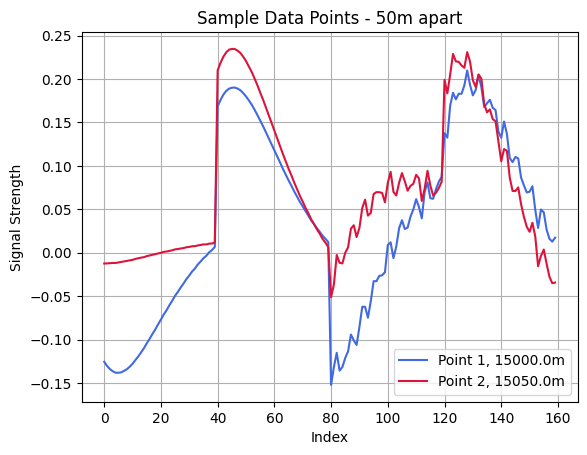

<Figure size 640x480 with 0 Axes>

In [41]:
# Finding which raw/normalized data point is at 15km
index = np.where(yraw == 15000)[0][0]

# Note: pretty sure I should use y-value distances from the "raw" dataset not the training set (like above cell) since the x_norm dataset is from x_norm=normalize(Xraw)
plt.plot(x_norm[index], c='royalblue'  , label=f"Point 1, {yraw[index]}m")
plt.plot(x_norm[index + 1], c='crimson', label=f"Point 2, {yraw[index + 1]}m")
plt.legend(loc='lower right')
plt.grid()
py.xlabel("Index")
py.ylabel("Signal Strength")
py.title("Sample Data Points - 50m apart")

# Training was done on the normalized data so it makes sense that the blue lines look the same
plt.figure()

If we really squint we might be able to see some similarity in shape, but really they're very different. This is a problem for network training. What's going on is that we're measuring a signal every 50m when it's oscillating at the scale of centimeters. It's as if we're measuring a sin wave at the integers, i.e. sin(1), sin(2), sin(3), etc. It'll look like we're generating random numbers even though we're measuring something specific.

We need to do some feature engineering!

To account for this all we need to do is rotate the complex numbers that make up the vector. What we do is compute the angle of the very first complex entry in the vector. We rotate the entire vector by the exact angle that makes the first entry positive real.

As a formula, we're doing this:

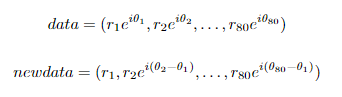

In [42]:
def rotate(normedX):

    rows = normedX.shape[0]
    cols = normedX.shape[1]

    #rotate back
    angle_h = np.arctan(normedX[:,40]/normedX[:,0]).reshape((rows, 1))
    angle_v = np.arctan(normedX[:,120]/normedX[:,80]).reshape((rows, 1))

    realparts_h = normedX[:,0:40]
    imagparts_h = normedX[:,40:80]


    output = np.zeros_like(normedX)

    output[:,0:40] = np.cos(angle_h)*realparts_h + np.sin(angle_h) * imagparts_h
    output[:,40:80] = -np.sin(angle_h)*realparts_h + np.cos(angle_h) * imagparts_h


    realparts_v = normedX[:,80:120]
    imagpart_v = normedX[:,120:160]
    output[:,80:120] = np.cos(angle_v)*realparts_v + np.sin(angle_v) * imagpart_v
    output[:,120:160] = -np.sin(angle_v)*realparts_v + np.cos(angle_v) * imagpart_v

    output[:,0:80] = np.sign(output[:,0]).reshape((rows,1)) * output[:,0:80]
    output[:,80:160] = np.sign(output[:,80]).reshape((rows,1)) * output[:,80:160]

    return output

Let's take another look at our data once we apply this rotation:

<Figure size 640x480 with 0 Axes>

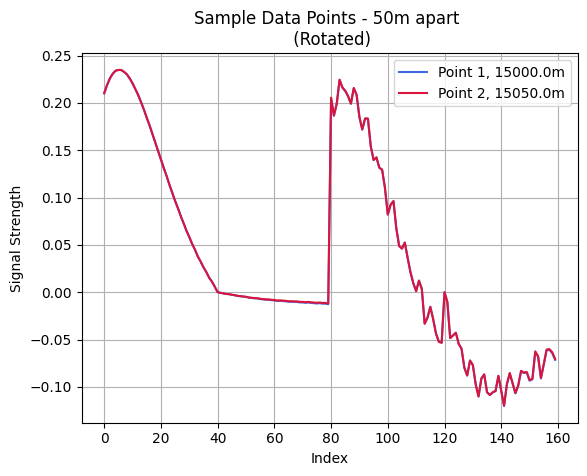

<Figure size 640x480 with 0 Axes>

In [43]:
# Finding which raw/normalized data point is at 15km
index = np.where(yraw == 15000)[0][0]

plt.plot(rotate(x_norm)[index], c='royalblue', label=f'Point 1, {yraw[index]}m')
plt.plot(rotate(x_norm)[index + 1], c='crimson', label=f'Point 2, {yraw[index + 1]}m')
plt.legend()
plt.grid()
py.xlabel("Index")
py.ylabel("Signal Strength")
py.title("Sample Data Points - 50m apart \n (Rotated)")
plt.figure()

Now they're nearly identical! This might be good for our network training - it's easier to train if similar inputs lead to similar outputs.

## **Question 7** **(10 points)**

**Part 1 (10 points)** Design and train a NN with rotated data `X`, you should be able to get a good result by turning your hyperparameters (`batch size`, `number of epochs`, `learning rate`).

Hint:

XTrain_rotated=rotate(XTrain)

XTest_rotated=rotate(XTest)

model_r = YourNetwork().cuda()

batch_size = 50, 100, 200

num_epochs = 500,1000, 2000

learning_rate = 1e-2, 1e-3, 1e-4

criterion = nn.MSELoss()

network_r, losses = train(XTrain_rotated, yTrain, model_r, num_epochs, learning_rate, batch_size, criterion, print_interval)

**Brief Analysis**: 

Used a neat package called `Optuna` to efficiently iterate through the suggested hyperparameter options and values. Found the best combination to be 'epochs': 2000, 'learning_rate': 0.001, 'batch_size': 50 - (takes about 16mins). The result is a NN that **dramatically outperforms all previous approaches**. Slightly better in training than testing - which is a good sign, and an $R^2$ of ~1. All other performance metrics are at **least one factor of magnitute better** than all previous approaches. 


In [44]:
# Import statements
%pip install -q optuna
import optuna as tuna
import copy

# Network information:
network_act_fcn = nn.LeakyReLU()
network_name    = "Your NN with rotated X"
network_rotated = mynetwork_3_Q5(activation_function=network_act_fcn).to(DEVICE) # DEVICE code already defaults to Cuda if available, see sample code

# Training settings:
batch_size = [50,100,200]
num_epochs = [500,1000,2000]
learning_rate = [1e-2,1e-3,1e-4]
criterion = nn.MSELoss()
print_interval= 100
best_score = np.inf # default value of best performance is infinity
best_network = None
best_hyperparams = {}

# Data setup:
XTrain_Q7 = rotate(XTrain)
yTrain_Q7 = yTrain.copy()
yTest_Q7  = yTest.copy()
XTest_Q7  = rotate(XTest)

def objective(trial: tuna.Trial):
    hyperparams = {
        "epochs": trial.suggest_categorical("num_epochs", num_epochs),
        "learning_rate": trial.suggest_categorical("learning_rate", learning_rate),
        "batch_size": trial.suggest_categorical("batch_size", batch_size)
    }
    print(hyperparams)

    global best_score, best_network, best_hyperparams
    network_temporal = copy.deepcopy(network_rotated)
    network_temporal, losses = train(**hyperparams, network=network_temporal, training_inputs= XTrain_Q7, training_outputs= yTrain_Q7, loss_function=criterion, print_interval=print_interval)
    eval_metrics = model_eva(XTrain_Q7, XTest_Q7, yTrain_Q7, yTest_Q7, network_temporal)
    print(eval_metrics)
    if eval_metrics[0] < best_score:
        best_score = eval_metrics[0]
        best_network = network_temporal
        best_hyperparams = hyperparams
    
    return eval_metrics[0]

def search_models():
    study = tuna.create_study(direction= "minimize")
    study.optimize(objective, n_trials=27)
    print(f"Final best score: {best_score}")
    print(best_hyperparams)

search_models()

if any(network_name in sublist for sublist in results):
    results = results[:-1] # in-case removal is required during debugging
    MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test = model_eva(XTrain_Q7,XTest_Q7,yTrain_Q7,yTest_Q7,best_network)
    results.append([network_name,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test]) 
else: 
    MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test = model_eva(XTrain_Q7,XTest_Q7,yTrain_Q7,yTest_Q7,best_network)
    results.append([network_name,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test])
    
print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

[I 2026-03-31 13:40:43,724] A new study created in memory with name: no-name-4cdd50b7-1470-4891-b732-da36dd5773f9


{'epochs': 1000, 'learning_rate': 0.0001, 'batch_size': 50}
epoch:  100 training loss: 4.072e+04 time:    2.8
epoch:  200 training loss: 2.019e+04 time:    6.3
epoch:  300 training loss: 1.373e+04 time:    8.9
epoch:  400 training loss: 1.304e+04 time:   11.6
epoch:  500 training loss: 9.645e+03 time:   14.4
epoch:  600 training loss: 9.258e+03 time:   17.7
epoch:  700 training loss: 8.900e+03 time:   20.5
epoch:  800 training loss: 7.567e+03 time:   23.3
epoch:  900 training loss: 7.678e+03 time:   25.9


[I 2026-03-31 13:41:12,535] Trial 0 finished with value: 7052.4921269734705 and parameters: {'num_epochs': 1000, 'learning_rate': 0.0001, 'batch_size': 50}. Best is trial 0 with value: 7052.4921269734705.


epoch: 1000 training loss: 9.497e+03 time:   28.8
(7052.4921269734705, 78161661.50339608, np.float64(8840.908409399799), 0.6873689061410677, 7114.524633220349, 80844528.98547475, np.float64(8991.358572845082), 0.6842388375150641)
{'epochs': 500, 'learning_rate': 0.0001, 'batch_size': 50}
epoch:  100 training loss: 4.302e+04 time:    3.1
epoch:  200 training loss: 2.083e+04 time:    5.7
epoch:  300 training loss: 1.310e+04 time:    8.3
epoch:  400 training loss: 1.238e+04 time:   11.1


[I 2026-03-31 13:41:27,164] Trial 1 finished with value: 9298.596677246094 and parameters: {'num_epochs': 500, 'learning_rate': 0.0001, 'batch_size': 50}. Best is trial 0 with value: 7052.4921269734705.


...

epoch: 2000 training loss: 1.627e+02 time:   36.7
(125.8254248046875, 26539.760134310724, np.float64(162.91028246955662), 0.9999091709516406, 131.37419567647672, 32135.593551246973, np.float64(179.26403306644357), 0.9998964789038021)
{'epochs': 2000, 'learning_rate': 0.01, 'batch_size': 100}
epoch:  100 training loss: 7.759e+03 time:    1.6
epoch:  200 training loss: 5.851e+03 time:    3.5
epoch:  300 training loss: 6.128e+03 time:    5.6
epoch:  400 training loss: 1.891e+03 time:    7.2
epoch:  500 training loss: 1.095e+03 time:    8.9
epoch:  600 training loss: 8.753e+02 time:   10.6
epoch:  700 training loss: 4.300e+02 time:   12.2
epoch:  800 training loss: 1.590e+02 time:   13.9
epoch:  900 training loss: 2.542e+02 time:   15.8
epoch: 1000 training loss: 3.093e+02 time:   18.0
epoch: 1100 training loss: 1.599e+02 time:   19.6
epoch: 1200 training loss: 1.798e+02 time:   21.2
epoch: 1300 training loss: 1.668e+02 time:   22.8
epoch: 1400 training loss: 2.332e+02 time:   24.5
epoch: 

[I 2026-03-31 13:52:47,665] Trial 25 finished with value: 180.7158349609375 and parameters: {'num_epochs': 2000, 'learning_rate': 0.01, 'batch_size': 100}. Best is trial 19 with value: 66.000654296875.


epoch: 2000 training loss: 1.585e+02 time:   35.1
(180.7158349609375, 44244.02118226528, np.float64(210.3426280673161), 0.9998469159087563, 188.83335879003744, 56293.00139659653, np.float64(237.26146209740116), 0.9998170795289956)
{'epochs': 2000, 'learning_rate': 0.01, 'batch_size': 100}
epoch:  100 training loss: 7.612e+03 time:    1.7
epoch:  200 training loss: 6.160e+03 time:    3.3
epoch:  300 training loss: 5.375e+03 time:    5.1
epoch:  400 training loss: 2.453e+03 time:    7.5
epoch:  500 training loss: 9.597e+02 time:    9.1
epoch:  600 training loss: 5.982e+02 time:   10.8
epoch:  700 training loss: 3.151e+02 time:   12.5
epoch:  800 training loss: 3.105e+02 time:   14.2
epoch:  900 training loss: 2.828e+02 time:   15.8
epoch: 1000 training loss: 1.897e+02 time:   17.5
epoch: 1100 training loss: 3.079e+02 time:   19.8
epoch: 1200 training loss: 2.224e+02 time:   21.5
epoch: 1300 training loss: 5.676e+02 time:   23.1
epoch: 1400 training loss: 1.537e+02 time:   24.9
epoch: 150

[I 2026-03-31 13:53:23,779] Trial 26 finished with value: 63.47589192708333 and parameters: {'num_epochs': 2000, 'learning_rate': 0.01, 'batch_size': 100}. Best is trial 26 with value: 63.47589192708333.


epoch: 2000 training loss: 1.075e+02 time:   36.1
(63.47589192708333, 8465.290703035991, np.float64(92.00701442301012), 0.9999708991249686, 78.56183704242929, 17589.62150239865, np.float64(132.6258704114648), 0.9999431754477022)
Final best score: 63.47589192708333
{'epochs': 2000, 'learning_rate': 0.01, 'batch_size': 100}
+------------------------+----------------+-----------------+-----------------+-----------------+------------+------------------+-------------+-----------------+
| Model                  |   Training MAE |    Training MSE |   Training RMSE |    Training R^2 |   Test MAE |         Test MSE |   Test RMSE |        Test R^2 |
+========================+================+=================+=================+=================+============+==================+=============+=================+
| Linear regression      |     10925.1    |     1.92709e+08 |       13882     |    -0.958455    | 52082.7    |      5.8753e+10  |  242390     |    -0.0213765   |
+------------------------+--

# Cross weather evaluation.

Next, we want to see how well this model would perform on new kinds of data.

There's a huge part of this problem that we haven't discussed yet - the weather conditions make an enormous difference when it comes to the electric field! In particular, the most important of these weather conditions is the evaporation duct we mentioned earlier. Recall that the duct traps the signal, the signal bounces around in the duct, and that allows us to get good range predictions. The key difficulty in this problem is that the electric field you get when the duct is 20 meters tall is very very different from the electric field you get when the duct is 25 meters tall. All the data we've used so far comes from a 25 meter duct.

There's a crucial question here - **if the weather today is different from the weather yesterday, can we still make good range predictions?**

Imagine the following: we go out one day and collect training data for this problem, and the weather for that day was such that the evaporation duct was 25m tall. We train our neural network and make great predictions. The next day, we try to go out and use our neural network in the field to make range predictions, but the weather is different - the duct height is 24m. Can we still do a good job? We need to figure out what kind of performance we can expect in different weather conditions.

The next file has some electric field data for different weather conditions.

Our previous data set was 1 electric field coming from a duct height of 25m. This next data set has 4 electric fields coming from duct heights of 23, 23.5, 24, and 24.5 meters. Let's test and see how well our network does on these data sets.

Let's load new data for the evaluation.

In [44]:
arrays2 = {}

filepath = ['cs3data2.h5']
numfiles = len(filepath)
f = 0
for i in range(numfiles):
    f = h5py.File(filepath[i], 'r')
    for k, v in f.items():
        arrays2[k] = v

# display what data we have
for key in arrays2.keys():
    print(key, arrays2[key])

duct_height_save <HDF5 dataset "duct_height_save": shape (1, 4), type "<f8">
field_H_imag_save <HDF5 dataset "field_H_imag_save": shape (4, 1201, 40), type "<f8">
field_H_real_save <HDF5 dataset "field_H_real_save": shape (4, 1201, 40), type "<f8">
field_V_imag_save <HDF5 dataset "field_V_imag_save": shape (4, 1201, 40), type "<f8">
field_V_real_save <HDF5 dataset "field_V_real_save": shape (4, 1201, 40), type "<f8">
range_grid <HDF5 dataset "range_grid": shape (1201, 1), type "<f8">


In [45]:
# what are our new test duct heights?
duct_heights = np.array(arrays2['duct_height_save']).reshape(-1)
print(duct_heights)

[23.  23.5 24.  24.5]


In [46]:
numfields =  4
numranges = 1201

#get the electric field data and reshape everything into one np array

test_data_h_real = np.array(arrays2['field_H_real_save']).reshape(numfields, numranges, 40)
test_data_h_imag = np.array(arrays2['field_H_imag_save']).reshape(numfields, numranges, 40)
test_data_v_real = np.array(arrays2['field_V_real_save']).reshape(numfields, numranges, 40)
test_data_v_imag = np.array(arrays2['field_V_imag_save']).reshape(numfields, numranges, 40)

XTest_otherducts = []
XTest_otherducts += [[test_data_h_real*1, test_data_h_imag*1, test_data_v_real*1, test_data_v_imag*1]]
XTest_otherducts = np.block(XTest_otherducts)
print(XTest_otherducts.shape)

# get the target range data

ranges = np.array(arrays2['range_grid']).reshape((numranges))

yTest_otherducts = []
yTest_otherducts += [ranges]
yTest_otherducts = np.block(yTest_otherducts)
print(yTest_otherducts.shape)

(4, 1201, 160)
(1201,)


Let test our network on all 4 of these data sets.

In [47]:
MAE_train_nn3_w1,MSE_train_nn3_w1,RMSE_train_nn3_w1,R2_train_nn3_w1,MAE_test_nn3_w1,MSE_test_nn3_w1,RMSE_test_nn3_w1,R2_test_nn3_w1 = model_eva(XTrain,normalize(XTest_otherducts[0]),yTrain,yTest_otherducts,network_3)
MAE_train_nn3_w2,MSE_train_nn3_w2,RMSE_train_nn3_w2,R2_train_nn3_w2,MAE_test_nn3_w2,MSE_test_nn3_w2,RMSE_test_nn3_w2,R2_test_nn3_w2 = model_eva(XTrain,normalize(XTest_otherducts[1]),yTrain,yTest_otherducts,network_3)
MAE_train_nn3_w3,MSE_train_nn3_w3,RMSE_train_nn3_w3,R2_train_nn3_w3,MAE_test_nn3_w3,MSE_test_nn3_w3,RMSE_test_nn3_w3,R2_test_nn3_w3 = model_eva(XTrain,normalize(XTest_otherducts[2]),yTrain,yTest_otherducts,network_3)
MAE_train_nn3_w4,MSE_train_nn3_w4,RMSE_train_nn3_w4,R2_train_nn3_w4,MAE_test_nn3_w4,MSE_test_nn3_w4,RMSE_test_nn3_w4,R2_test_nn3_w4 = model_eva(XTrain,normalize(XTest_otherducts[3]),yTrain,yTest_otherducts,network_3)

In [48]:
results.append(["NN_3_weather_1",MAE_train_nn3_w1,MSE_train_nn3_w1,RMSE_train_nn3_w1,R2_train_nn3_w1,MAE_test_nn3_w1,MSE_test_nn3_w1,RMSE_test_nn3_w1,R2_test_nn3_w1])
results.append(["NN_3_weather_2",MAE_train_nn3_w2,MSE_train_nn3_w2,RMSE_train_nn3_w2,R2_train_nn3_w2,MAE_test_nn3_w2,MSE_test_nn3_w2,RMSE_test_nn3_w2,R2_test_nn3_w2])
results.append(["NN_3_weather_3",MAE_train_nn3_w3,MSE_train_nn3_w3,RMSE_train_nn3_w3,R2_train_nn3_w3,MAE_test_nn3_w3,MSE_test_nn3_w3,RMSE_test_nn3_w3,R2_test_nn3_w3])
results.append(["NN_3_weather_4",MAE_train_nn3_w4,MSE_train_nn3_w4,RMSE_train_nn3_w4,R2_train_nn3_w4,MAE_test_nn3_w4,MSE_test_nn3_w4,RMSE_test_nn3_w4,R2_test_nn3_w4])

In [50]:
print (tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

+------------------------+----------------+-----------------+-----------------+-----------------+------------+------------------+-------------+-----------------+
| Model                  |   Training MAE |    Training MSE |   Training RMSE |    Training R^2 |   Test MAE |         Test MSE |   Test RMSE |        Test R^2 |
+========================+================+=================+=================+=================+============+==================+=============+=================+
| Linear regression      |     10925.1    |     1.92709e+08 |       13882     |    -0.958455    | 52082.7    |      5.8753e+10  |  242390     |    -0.0213765   |
+------------------------+----------------+-----------------+-----------------+-----------------+------------+------------------+-------------+-----------------+
| KNeighbors (n=2)       |      2767.29   |     2.16438e+07 |        4652.29  |     0.921701    |  5368.51   |      5.84804e+07 |    7647.25  |     0.785438    |
+------------------------+--

## **Question 8** **(20 points)**

**Part 1 (5 points)**

What are your observations here? Does the model perform well in all different weather?


**Part 1 (15 points)**

Merge all data of different weather together, and then retrain the model. Can you acheive a better performance? Report you results.

Hint:

Using `np.concatenate` to merge to data. eg,
```python
XTrain_all = np.concatenate([XTrain1, XTrain2])
```



## **Q8: Answer**


**Part 1**

My observation is that the model does not perform well in all weather conditions. It was trained only on the 25 m duct data, so when the weather changes, the electric field pattern also changes a lot. Because of that, the model does not generalize well to all different weather cases. It should perform best on the weather closest to the training data and worse on the others.

**Part 2**

These results are very good. The test R² is very close to 1, which means the model explains almost all of the variation in the target data. Also, the test MAE and test RMSE are both low, so the prediction error is small. Another good sign is that the training and test results are very close to each other, which means the model is not overfitting too much.

So based on this, I can say that retraining with the merged weather dataset worked much better. The new model is more robust and can handle different weather conditions much better than a model trained on only one duct case.

In [49]:
#part 2

X_all_weather = []
y_all_weather = []

X_all_weather += [Xraw]
y_all_weather += [yraw]

for i in range(4):
    X_all_weather += [XTest_otherducts[i]]
    y_all_weather += [yTest_otherducts]

X_all_weather = np.concatenate(X_all_weather, axis=0)
y_all_weather = np.concatenate(y_all_weather, axis=0)

print(X_all_weather.shape)
print(y_all_weather.shape)

(6005, 160)
(6005,)


In [50]:
# normalize and rotate all data
X_all_weather_norm = normalize(X_all_weather)
X_all_weather_rot = rotate(X_all_weather_norm)

In [51]:
# split merged data
XTrain_all, XTest_all, yTrain_all, yTest_all = train_test_split(
    X_all_weather_rot, y_all_weather, test_size=0.2, random_state=50
)

In [52]:
class mynetwork_all_weather(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,100),
            nn.LeakyReLU(),
            nn.Linear(100,80),
            nn.LeakyReLU(),
            nn.Linear(80,50),
            nn.LeakyReLU(),
            nn.Linear(50,1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x

In [53]:
torch.manual_seed(50)

model_all_weather = mynetwork_all_weather().to(DEVICE)

batch_size = 50
num_epochs = 2000
learning_rate = 1e-3
criterion = nn.MSELoss()
print_interval = 100

network_all_weather, losses_all_weather = train(
    XTrain_all, yTrain_all,
    model_all_weather,
    num_epochs,
    learning_rate,
    batch_size,
    criterion,
    print_interval
)

epoch:  100 training loss: 3.995e+03 time:   18.8
epoch:  200 training loss: 4.055e+03 time:   37.4
epoch:  300 training loss: 1.790e+03 time:   56.2
epoch:  400 training loss: 1.109e+03 time:   74.9
epoch:  500 training loss: 1.186e+03 time:   93.9
epoch:  600 training loss: 1.356e+03 time:  112.6
epoch:  700 training loss: 5.834e+02 time:  131.4
epoch:  800 training loss: 3.836e+02 time:  150.5
epoch:  900 training loss: 5.501e+02 time:  169.3
epoch: 1000 training loss: 7.933e+02 time:  188.0
epoch: 1100 training loss: 3.149e+02 time:  206.7
epoch: 1200 training loss: 4.901e+02 time:  225.6
epoch: 1300 training loss: 5.391e+02 time:  244.2
epoch: 1400 training loss: 7.824e+02 time:  262.8
epoch: 1500 training loss: 7.110e+02 time:  281.4
epoch: 1600 training loss: 7.913e+02 time:  300.6
epoch: 1700 training loss: 6.674e+02 time:  319.7
epoch: 1800 training loss: 4.060e+02 time:  338.6
epoch: 1900 training loss: 3.447e+02 time:  357.9
epoch: 2000 training loss: 2.481e+02 time:  376.5


In [54]:
MAE_train_all,MSE_train_all,RMSE_train_all,R2_train_all,MAE_test_all,MSE_test_all,RMSE_test_all,R2_test_all = model_eva(
    XTrain_all,XTest_all,yTrain_all,yTest_all,network_all_weather
)

results.append([
    "NN_all_weather",
    MAE_train_all,MSE_train_all,RMSE_train_all,R2_train_all,
    MAE_test_all,MSE_test_all,RMSE_test_all,R2_test_all
])

print(tabulate(
    results,
    headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],
    tablefmt="grid"
))

+------------------------+----------------+------------------+-----------------+-----------------+------------+------------------+-------------+-----------------+
| Model                  |   Training MAE |     Training MSE |   Training RMSE |    Training R^2 |   Test MAE |         Test MSE |   Test RMSE |        Test R^2 |
+========================+================+==================+=================+=================+============+==================+=============+=================+
| Linear regression      |     10925.1    |      1.92709e+08 |       13882     |    -0.958458    |  52085.1   |      5.87647e+10 |  242414     |    -0.0213728   |
+------------------------+----------------+------------------+-----------------+-----------------+------------+------------------+-------------+-----------------+
| KNeighbors (n=2)       |      2767.29   |      2.16438e+07 |        4652.29  |     0.921701    |   5368.51  |      5.84804e+07 |    7647.25  |     0.785438    |
+---------------------

In [ ]:
# results.append(["Your NN all weather"," "," "," "," "," "," "," "," "])
# print (tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

## **Question 9** **($\infty$ points, since this is where you really learn stuff! :-)**

You can get as many points of extra credit as you like by doing a good job with this question!

Play around with doing a better analysis.  Things to try:

1.   We already know the power of neural networks, so is it possible to overfit them? How can we prevent the overfitting of neural networks? There are two common techniques widely used for regularization: Dropout and Batch Normalization. Try to use them in your networks, do the networks perform better than others?
Here are several examples in Pytorch:
https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html,
https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html


2.  The Real-world signals are often noisy, can we add Gaussian noise to our training samples to simulate the signal and improve model performance? You might get inspiration from the paper [Deep Learning for Range Localization via Over-Water Electromagnetic Signals](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9680246). Try to do some feature engineering and report your results. If you have any great ideas, please don't hesitate to tell Randy 🧙, he can help you publish a paper at top conferences and shine your resume. 👀






In [ ]:
# Class definition using Batch Normalization (1D):
class mynetwork_batchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(160,100),
            nn.BatchNorm1d(100),
            nn.LeakyReLU(),
            nn.Linear(100,80),
            nn.BatchNorm1d(80),
            nn.LeakyReLU(),
            nn.Linear(80,50),
            nn.BatchNorm1d(50),
            nn.LeakyReLU(),
            nn.Linear(50,1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x
    
# Function that runs the training and evaluation:
def run_train_and_eva(XTrain, yTrain):
    torch.manual_seed(50)
    this_model = mynetwork_batchNorm().to(DEVICE)
    this_name = "NN_all_weather (BatchNorm)"

    batch_size = 50
    num_epochs = 2000
    learning_rate = 1e-3
    criterion = nn.MSELoss()
    print_interval = 100

    this_model, this_losses = train(
        XTrain, yTrain,
        model_all_weather,
        num_epochs,
        learning_rate,
        batch_size,
        criterion,
        print_interval
    )

    if any(this_name in sublist for sublist in results):
        results = results[:-1] # remove entry if already there

        MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test = model_eva(XTrain,XTest_all,yTrain,yTest_all,this_model)
        results.append([network_name,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test]) 
    else: 
        MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test = model_eva(XTrain,XTest_all,yTrain,yTest_all,this_model)
        results.append([network_name,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test])

